--- Step 1: Constructing the Monthly Supply Chain Dataset ---
  [OK] Loaded and processed US_CPI_Total
  [OK] Loaded and processed Chip_PPI
  [OK] Loaded and processed Auto_PPI
  [OK] Loaded and processed Auto_CPI
  [OK] Loaded and processed JPY_Rate

--- Monthly Dataset Ready (108 months) and Saved ---
            US_CPI_Total   Chip_PPI    Auto_PPI    Auto_CPI    JPY_Rate
Date                                                                   
2016-01-31    100.000000  100.00000  100.000000  100.000000  100.000000
2016-02-29     99.867032   99.82669  100.083333  100.455332   96.946276
2016-03-31    100.180095   99.82669  100.000000  100.502365   95.522085
2016-04-30    100.563850   99.65338  100.000000  100.345589   92.663289
2016-05-31    100.801592   99.65338  100.000000  100.319687   92.067979


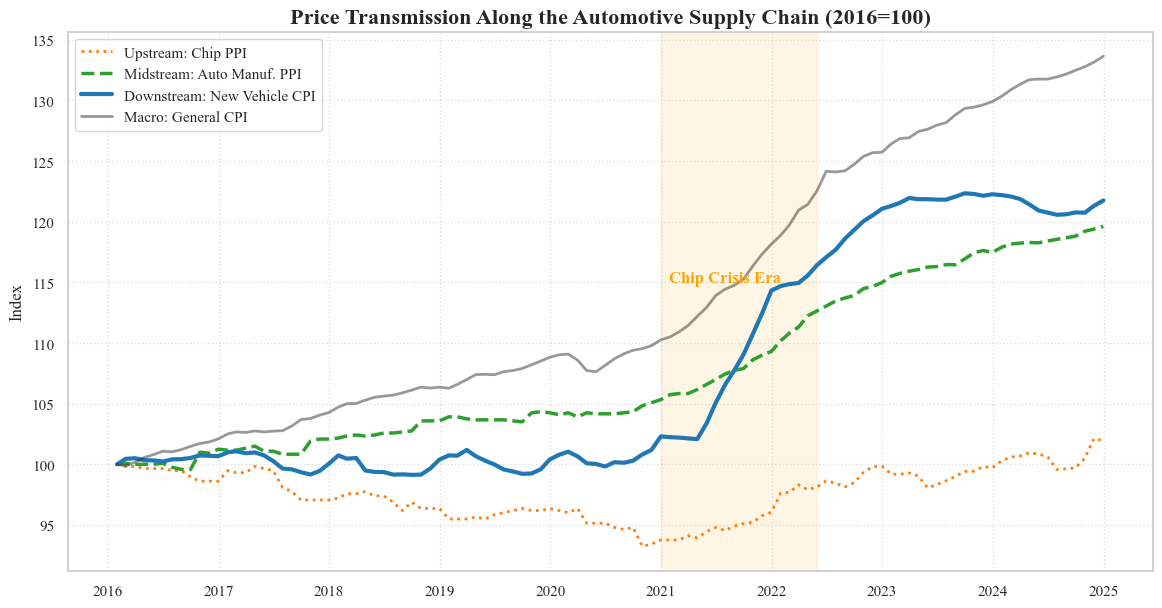

[SUCCESS] Figure 5 and the underlying dataset have been saved.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE_DIR = r"G:\jupyter\2025APMCM"
MACRO_DIR = os.path.join(BASE_DIR, "US_Macroeconomic")
IMG_DIR = os.path.join(BASE_DIR, "Cleaned_Data")
os.makedirs(IMG_DIR, exist_ok=True)

files_map = {
    'US_CPI_Total': 'US_CPI_2015_2025.csv',
    'Chip_PPI': 'US_PCU33443344_2015_2025.csv',
    'Auto_PPI': 'US_PCU336336_2015_2025.csv',
    'Auto_CPI': 'US_CUSR0000SETA01_2015_2025.csv',
    'JPY_Rate': 'US_DEXJPUS_2015_2025.csv'
}
dfs = []
for label, fname in files_map.items():
    fpath = os.path.join(MACRO_DIR, fname)
    df = pd.read_csv(fpath)
    date_col = [c for c in df.columns if 'date' in c.lower()][0]
    val_col = [c for c in df.columns if c != date_col][0]
    df = df[[date_col, val_col]].copy()
    df.columns = ['Date', label]
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    df[label] = pd.to_numeric(df[label], errors='coerce')
    df = df.resample('ME').mean().interpolate(method='linear')
    dfs.append(df)

df_final = pd.concat(dfs, axis=1).dropna()
base_date = '2016-01-31'
df_norm = df_final / df_final.loc[base_date] * 100
df_norm = df_norm['2016-01-01':'2024-12-31']

out_path = os.path.join(IMG_DIR, "Supply_Chain_Dataset.csv")
df_norm.to_csv(out_path)

sns.set_theme(style="whitegrid", font="Times New Roman")
plt.figure(figsize=(14, 7))
plt.plot(df_norm.index, df_norm['Chip_PPI'], label='Upstream: Chip PPI', lw=2, ls=':', color='#ff7f0e')
plt.plot(df_norm.index, df_norm['Auto_PPI'], label='Midstream: Auto Manuf. PPI', lw=2.5, ls='--', color='#2ca02c')
plt.plot(df_norm.index, df_norm['Auto_CPI'], label='Downstream: New Vehicle CPI', lw=3, ls='-', color='#1f77b4')
plt.plot(df_norm.index, df_norm['US_CPI_Total'], label='Macro: General CPI', lw=2, ls='-', color='#333333', alpha=0.5)
plt.title("Price Transmission Along the Automotive Supply Chain (2016=100)", fontsize=16, fontweight='bold')
plt.ylabel("Index")
plt.legend(frameon=True, fancybox=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.axvspan(pd.to_datetime('2021-01-01'), pd.to_datetime('2022-06-01'), color='orange', alpha=0.1)
plt.text(pd.to_datetime('2021-08-01'), 115, "Chip Crisis Era", color='orange', ha='center', fontweight='bold')
plt.savefig(os.path.join(IMG_DIR, "Figure_5_Supply_Chain_Indices.png"), dpi=300)
plt.show()

df_norm.head()

--- Step 2: Testing for Stationarity (ADF Test) ---
'US_CPI_Total': Non-stationary after 1st diff (p=0.4458). Applying 2nd difference (p=0.0000).
'Chip_PPI': Becomes stationary after 1st difference (p=0.0000).
'Auto_PPI': Non-stationary after 1st diff (p=0.5118). Applying 2nd difference (p=0.0227).
'Auto_CPI': Non-stationary after 1st diff (p=0.4002). Applying 2nd difference (p=0.0000).
'JPY_Rate': Becomes stationary after 1st difference (p=0.0000).


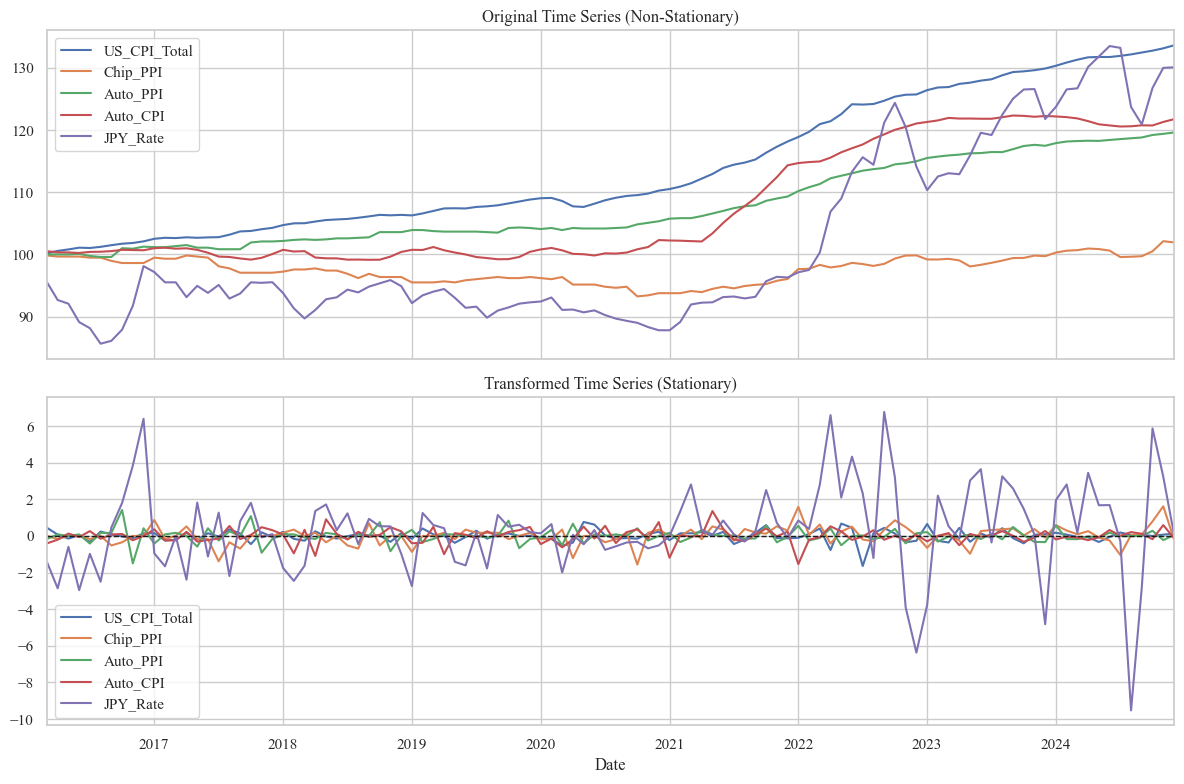


[SUCCESS] All series are now stationary and ready for modeling.


In [3]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import os

BASE_DIR = r"G:\jupyter\2025APMCM"
DATA_FILE = os.path.join(BASE_DIR, "Cleaned_Data", "Supply_Chain_Dataset.csv")
df_norm = pd.read_csv(DATA_FILE, index_col='Date', parse_dates=True)

df_stationary = pd.DataFrame()
for col in df_norm.columns:
    series = df_norm[col].dropna()
    series_d1 = series.diff().dropna()
    p_val_d1 = adfuller(series_d1)[1]
    if p_val_d1 <= 0.05:
        df_stationary[col] = series_d1
    else:
        series_d2 = series.diff().diff().dropna()
        df_stationary[col] = series_d2

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
df_norm.plot(ax=axes[0])
axes[0].set_title("Original Time Series (Non-Stationary)")
df_stationary.plot(ax=axes[1])
axes[1].set_title("Transformed Time Series (Stationary)")
axes[1].axhline(0, color='k', ls='--', lw=1)
plt.tight_layout()
plt.show()

var_input_data = df_stationary.copy()

--- Step 3: Modeling Cost Pass-Through with VARX ---
Building VARMAX(3, 0) model...


G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


--- VARMAX Model Summary ---
                              Statespace Model Results                              
Dep. Variable:     ['Auto_PPI', 'Auto_CPI']   No. Observations:                  106
Model:                              VARX(3)   Log Likelihood                 -65.929
                                + intercept   AIC                            169.858
Date:                      Fri, 21 Nov 2025   BIC                            220.463
Time:                              14:53:20   HQIC                           190.368
Sample:                          03-31-2016                                         
                               - 12-31-2024                                         
Covariance Type:                        opg                                         
Ljung-Box (L1) (Q):             0.12, 0.28   Jarque-Bera (JB):        295.62, 26.19
Prob(Q):                        0.72, 0.60   Prob(JB):                   0.00, 0.00
Heteroskedasticity (H):         0.25, 

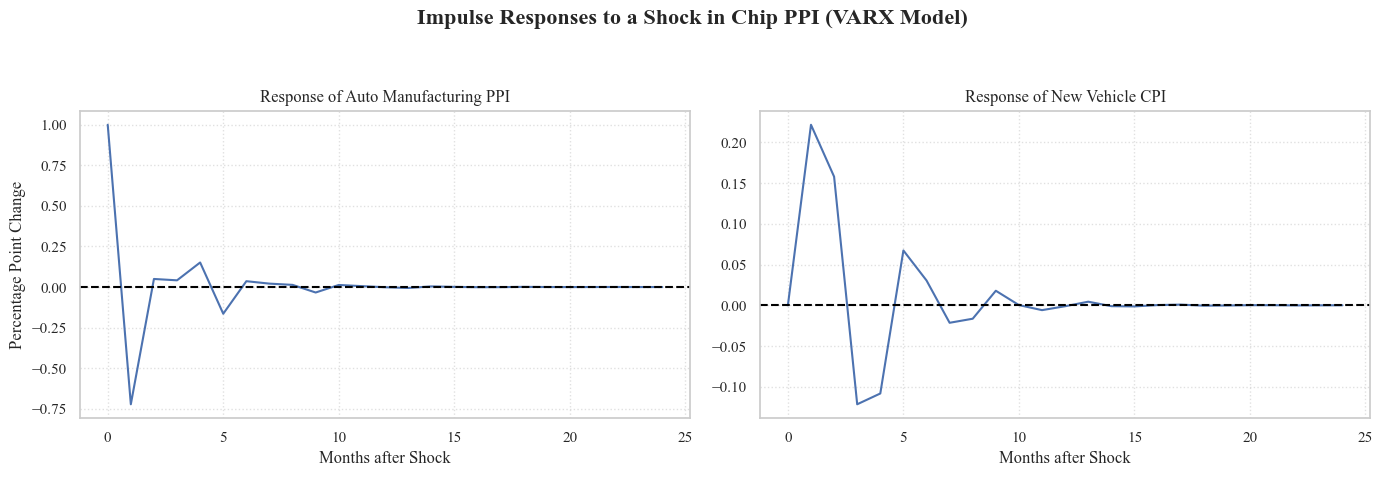

[SUCCESS] Figure 7 showing the cost pass-through effect has been saved.


In [4]:
from statsmodels.tsa.api import VARMAX
import pandas as pd
import matplotlib.pyplot as plt
import os

endog = var_input_data[['Auto_PPI', 'Auto_CPI']]
exog = var_input_data[['Chip_PPI']]
data = pd.concat([endog, exog], axis=1).dropna()
endog = data[['Auto_PPI', 'Auto_CPI']]
exog = data[['Chip_PPI']]

model = VARMAX(endog, order=(3, 0), exog=exog)
results = model.fit(disp=False)
exog_idx = results.model.exog_names.index('Chip_PPI')
irf = results.impulse_responses(steps=24, impulse=exog_idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impulse Responses to a Shock in Chip PPI (VARX Model)', fontsize=16, fontweight='bold')
irf['Auto_PPI'].plot(ax=axes[0])
axes[0].set_title('Response of Auto Manufacturing PPI')
axes[0].set_ylabel('Percentage Point Change')
irf['Auto_CPI'].plot(ax=axes[1])
axes[1].set_title('Response of New Vehicle CPI')
for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.axhline(0, color='black', ls='--')
    ax.set_xlabel('Months after Shock')
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig(os.path.join(IMG_DIR, "Figure_7_VARX_Impulse_Response.png"), dpi=300)
plt.show()

results.summary()


--- Step 4: Analyzing Exchange Rate Hedging Effects ---


G:\Anaconda3\envs\apmcm2025\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)



--- Hedging Analysis Results ---
Hedge Ratio Calculation: To offset a 1% cost shock, JPY needs to depreciate by 9.86%.


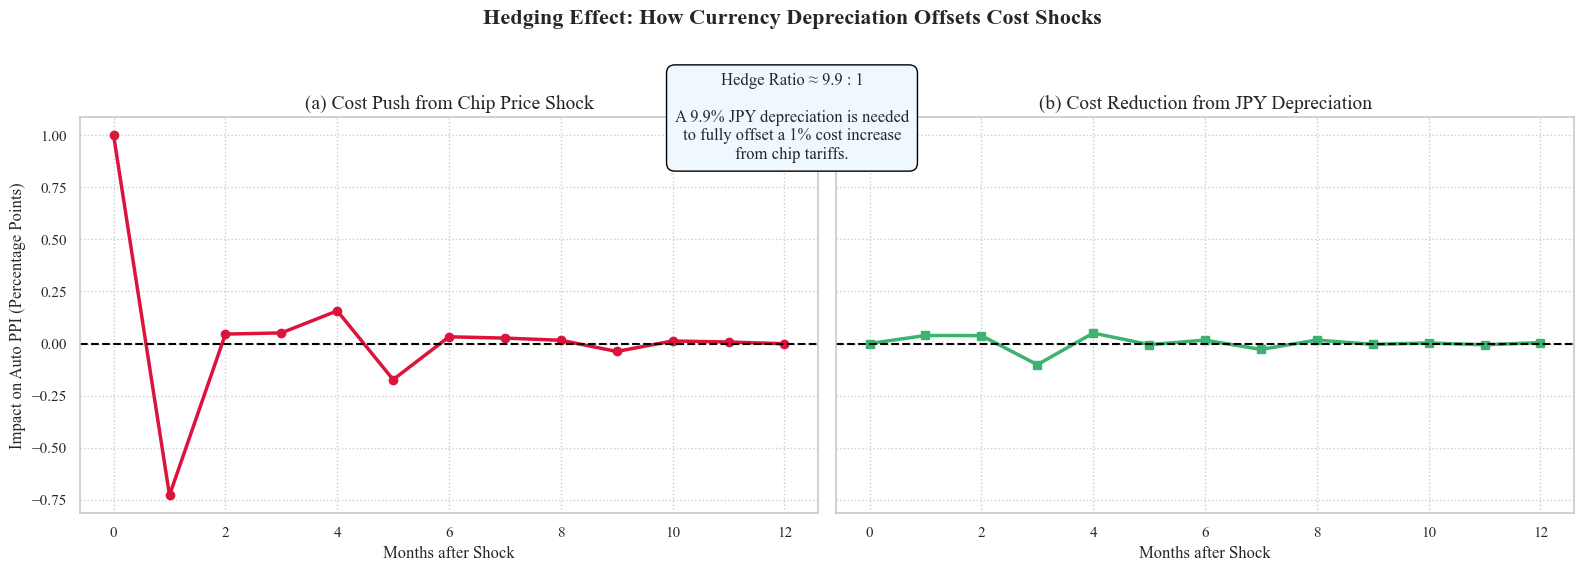

[SUCCESS] Figure 8 (corrected) showing the hedging analysis has been saved.


In [5]:
from statsmodels.tsa.api import VARMAX
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

endog = var_input_data[['Auto_PPI', 'Auto_CPI']]
exog = var_input_data[['Chip_PPI', 'JPY_Rate']]
data_hedge = pd.concat([endog, exog], axis=1).dropna()
endog_hedge = data_hedge[['Auto_PPI', 'Auto_CPI']]
exog_hedge = data_hedge[['Chip_PPI', 'JPY_Rate']]

model_hedge = VARMAX(endog_hedge, order=(3, 0), exog=exog_hedge)
results_hedge = model_hedge.fit(disp=False)

chip_idx = results_hedge.model.exog_names.index('Chip_PPI')
irf_chip = results_hedge.impulse_responses(steps=12, impulse=chip_idx)
jpy_idx = results_hedge.model.exog_names.index('JPY_Rate')
irf_jpy = results_hedge.impulse_responses(steps=12, impulse=jpy_idx)

chip_impact_on_auto_ppi = irf_chip['Auto_PPI'].max()
jpy_impact_on_auto_ppi = irf_jpy['Auto_PPI'].min()
hedge_ratio = -chip_impact_on_auto_ppi / jpy_impact_on_auto_ppi

sns.set_theme(style="whitegrid", font="Times New Roman")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Hedging Effect: How Currency Depreciation Offsets Cost Shocks', fontsize=16, fontweight='bold')
irf_chip['Auto_PPI'].plot(ax=axes[0], color='crimson', lw=2.5, marker='o')
axes[0].set_title('(a) Cost Push from Chip Price Shock', fontsize=14)
axes[0].set_xlabel('Months after Shock')
axes[0].set_ylabel('Impact on Auto PPI (Percentage Points)')
axes[0].axhline(0, color='black', ls='--')
axes[0].grid(True, linestyle=':')
irf_jpy['Auto_PPI'].plot(ax=axes[1], color='mediumseagreen', lw=2.5, marker='s')
axes[1].set_title('(b) Cost Reduction from JPY Depreciation', fontsize=14)
axes[1].set_xlabel('Months after Shock')
axes[1].axhline(0, color='black', ls='--')
axes[1].grid(True, linestyle=':')
fig.text(0.5, 0.8, f'Hedge Ratio ≈ {hedge_ratio:.1f} : 1\n\nA {hedge_ratio:.1f}% JPY depreciation is needed\nto fully offset a 1% cost increase\nfrom chip tariffs.',
         ha='center', va='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.5", fc='aliceblue', ec='black', lw=1))
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.savefig(os.path.join(IMG_DIR, "Figure_8_Hedging_Effect.png"), dpi=300)
plt.show()

print(f"Hedge Ratio: {hedge_ratio:.2f}")


--- Step 5: Simulating Strategic Scenarios for Japanese Automakers ---

[CONCLUSION] The optimal strategy under these assumptions is: 'FDI in Mexico'.


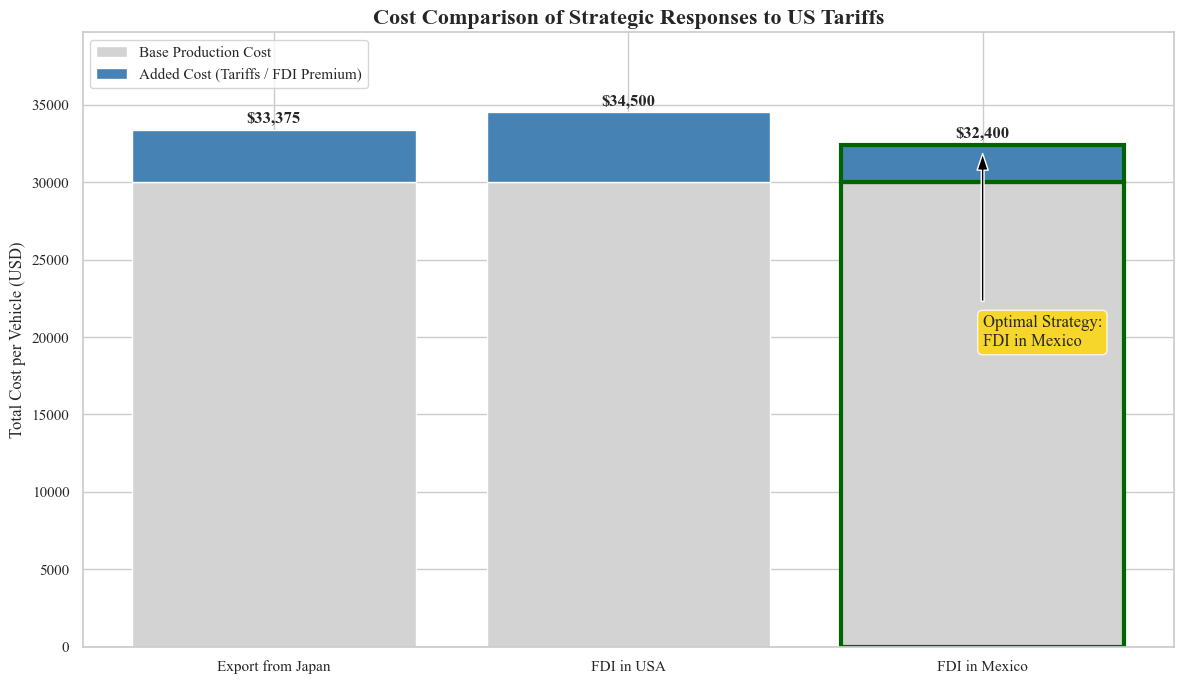

[SUCCESS] Figure 9 (corrected) showing the scenario analysis has been saved.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

avg_car_price_usd = 30000
chip_cost_share = 0.05
us_tariff_on_cars = 0.10
us_tariff_on_chips = 0.25
fdi_cost_premium_usa = 0.15
fdi_cost_premium_mexico = 0.05
logistics_from_mexico_share = 0.03

cost_chip_tariff = avg_car_price_usd * chip_cost_share * us_tariff_on_chips
cost_car_tariff = avg_car_price_usd * us_tariff_on_cars
added_cost_export = cost_chip_tariff + cost_car_tariff
total_cost_export = avg_car_price_usd + added_cost_export
added_cost_fdi_usa = avg_car_price_usd * fdi_cost_premium_usa
total_cost_fdi_usa = avg_car_price_usd * (1 + fdi_cost_premium_usa)
added_cost_fdi_mexico = avg_car_price_usd * (fdi_cost_premium_mexico + logistics_from_mexico_share)
total_cost_fdi_mexico = avg_car_price_usd * (1 + fdi_cost_premium_mexico) + avg_car_price_usd * logistics_from_mexico_share

costs = {
    "Export from Japan": total_cost_export,
    "FDI in USA": total_cost_fdi_usa,
    "FDI in Mexico": total_cost_fdi_mexico
}
best_strategy = min(costs, key=costs.get)

scenario_data = {
    'Strategy': ['Export from Japan', 'FDI in USA', 'FDI in Mexico'],
    'Base Cost': [avg_car_price_usd] * 3,
    'Added Cost (Tariffs/Premiums)': [added_cost_export, added_cost_fdi_usa, added_cost_fdi_mexico],
    'Total Cost': [total_cost_export, total_cost_fdi_usa, total_cost_fdi_mexico]
}
df_plot = pd.DataFrame(scenario_data).set_index('Strategy')

sns.set_theme(style="whitegrid", font="Times New Roman")
fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(df_plot.index, df_plot['Base Cost'], label='Base Production Cost', color='lightgray')
ax.bar(df_plot.index, df_plot['Added Cost (Tariffs/Premiums)'], bottom=df_plot['Base Cost'], label='Added Cost (Tariffs / FDI Premium)', color='steelblue')
best_idx = list(df_plot.index).index(best_strategy)
ax.patches[best_idx].set_edgecolor('darkgreen')
ax.patches[best_idx].set_linewidth(3)
ax.patches[best_idx + len(df_plot)].set_edgecolor('darkgreen')
ax.patches[best_idx + len(df_plot)].set_linewidth(3)
for i, total in enumerate(df_plot['Total Cost']):
    ax.text(i, total + 500, f'${total:,.0f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Figure 9: Cost Comparison of Strategic Responses to US Tariffs', fontsize=16, fontweight='bold')
ax.set_ylabel('Total Cost per Vehicle (USD)')
ax.set_ylim(0, df_plot['Total Cost'].max() * 1.15)
ax.legend(loc='upper left')
ax.annotate(f'Optimal Strategy:\n{best_strategy}', xy=(best_idx, df_plot.loc[best_strategy, 'Total Cost']), xytext=(best_idx, df_plot.loc[best_strategy, 'Total Cost'] * 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=8),
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="gold", alpha=0.8))
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "Figure_9_Scenario_Comparison.png"), dpi=300)
plt.show()

print(f"Optimal Strategy: '{best_strategy}'")